# Notebook 1 — FakeHealth · Descriptive Analysis of the Dataset
## HealthStory & HealthRelease: structure, fields, label distribution, class imbalance

**Project:** A Multi-Source Benchmark for CVD Health Misinformation Detection  
**Dataset:** FakeHealth — Dai, Sun & Wang (ICWSM 2020)  
**Repository:** https://github.com/EnyanDai/FakeHealth  

---
### What this notebook does
1. Check dependency installation
2. Load HealthStory and HealthRelease JSON files
3. Explore the structure and available fields
4. Binarize labels (rating < 3 → fake, ≥ 3 → real)
5. Analyze label distribution and class imbalance
6. Analyze text length and dominant topics
7. Visualize all key statistics
8. Export a CSV file ready for Notebook 2 (baseline classifier)


---
## Section 1 — Installation & imports
Toutes les librairies nécessaires. Exécutez cette cellule en premier.

In [2]:
# Dependencies for the notebook
#pip install pandas numpy matplotlib seaborn scikit-learn wordcloud

import os
import json
import glob
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Style global des graphiques
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print(' Imports OK')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')

 Imports OK
   pandas  2.3.3
   numpy   2.1.3


---
## Section 2 —  FakeHealth deposit
```
FakeHealth/
├── dataset/
│   ├── content/
│   │   ├── HealthStory/      ← fichiers JSON individuels
│   │   └── HealthRelease/    ← fichiers JSON individuels
│   └── engagements/
│   |    ├── HealthStory.json  ← IDs tweets/replies/retweets
│   |    └── HealthRelease.json  ← IDs tweets/replies/retweets
|   |    └── HealthStory.json
|   |    └── HealthRelease.json
|   └── reviews/
|       └── HealthStory.json
|       └── HealthRealase.json
└── README.md
```

In [4]:
# ── À MODIFIER selon votre installation ──────────────────────────────
REPO_ROOT = '../'   # chemin relatif ou absolu vers le dépôt cloné
# ─────────────────────────────────────────────────────────────────────

PATH_STORY   = os.path.join(REPO_ROOT, 'dataset', 'content', 'HealthStory')
PATH_RELEASE = os.path.join(REPO_ROOT, 'dataset', 'content', 'HealthRelease')
PATH_ENG_S   = os.path.join(REPO_ROOT, 'dataset', 'engagements', 'HealthStory.json')
PATH_ENG_R   = os.path.join(REPO_ROOT, 'dataset', 'engagements', 'HealthRelease.json')
PATH_REV_S   = os.path.join(REPO_ROOT, 'dataset', 'reviews', 'HealthStory.json')
PATH_REV_R   = os.path.join(REPO_ROOT, 'dataset', 'reviews', 'HealthRelease.json')

# Vérification des chemins
for path, label in [(PATH_STORY, 'HealthStory content'),
                    (PATH_RELEASE, 'HealthRelease content'),
                    (PATH_ENG_S, 'HealthStory engagements'),
                    (PATH_ENG_R, 'HealthRelease engagements'),
                    (PATH_REV_S, 'HealthStory reviews'),
                    (PATH_REV_R, 'HealthRelease reviews')]:
    status = 'loaded' if os.path.exists(path) else 'Not found'
    print(f'{status}  {label}: {path}')

loaded  HealthStory content: ../dataset/content/HealthStory
loaded  HealthRelease content: ../dataset/content/HealthRelease
loaded  HealthStory engagements: ../dataset/engagements/HealthStory.json
loaded  HealthRelease engagements: ../dataset/engagements/HealthRelease.json
loaded  HealthStory reviews: ../dataset/reviews/HealthStory.json
loaded  HealthRelease reviews: ../dataset/reviews/HealthRelease.json


---
## Section 3 — Chargement des fichiers JSON
Chaque article est un fichier JSON séparé. On itère le dossier et on construit un DataFrame.

In [13]:
def load_dataset(content_path, dataset_name):
    """
    Load all articles JSON from a given directory into a single DataFrame.
    Returns a DataFrame with one article per row.
    """
    records = []
    json_files = glob.glob(os.path.join(content_path, '*.json'))

    if len(json_files) == 0:
        raise FileNotFoundError(
            f'No .json files found in {content_path}\n'
            f'Check that REPO_ROOT is correct and that the repository is properly cloned.'
        )

    for fpath in json_files:
        with open(fpath, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
                data['file_id'] = os.path.basename(fpath).replace('.json', '')
                data['dataset'] = dataset_name
                records.append(data)
            except json.JSONDecodeError as e:
                print(f'Oops JSON error ignored: {fpath} - {e}')

    df = pd.DataFrame(records)
    print(f'{dataset_name} contents: {len(df)} articles loaded from {len(json_files)} files')
    return df


def load_reviews(review_path, dataset_name):
    """
    Load review metadata (including rating) from dataset/reviews/*.json.
    Returns a DataFrame with at least: file_id, rating_float
    """
    if not os.path.exists(review_path):
        raise FileNotFoundError(f'Reviews file not found: {review_path}')
    
    with open(review_path, 'r', encoding='utf-8') as f:
        reviews = json.load(f)
    
    df_rev = pd.DataFrame(reviews)
    if df_rev.empty:
        print(f'Warning: empty reviews file for {dataset_name}')
        return pd.DataFrame(columns=['file_id', 'rating_float'])
    
    if 'news_id' not in df_rev.columns:
        raise KeyError(f'news_id missing in reviews file: {review_path}')

    df_rev = df_rev.rename(columns={'news_id': 'file_id'})
    df_rev['rating_float'] = pd.to_numeric(df_rev.get('rating', np.nan), errors='coerce')

    keep_cols = ['file_id', 'rating_float']
    if 'category' in df_rev.columns:
        keep_cols.append('category')
    if 'news_source' in df_rev.columns:
        keep_cols.append('news_source')

    out = df_rev[keep_cols].drop_duplicates(subset=['file_id'])
    print(f' {dataset_name} reviews: {len(out)} rows loaded')
    return out


df_story = load_dataset(PATH_STORY, 'HealthStory')
df_release = load_dataset(PATH_RELEASE, 'HealthRelease')

reviews_story = load_reviews(PATH_REV_S, 'HealthStory')
reviews_release = load_reviews(PATH_REV_R, 'HealthRelease')

df_story = df_story.merge(reviews_story, on='file_id', how='left')
df_release = df_release.merge(reviews_release, on='file_id', how='left')

print(f"HealthStory ratings matched: {df_story['rating_float'].notna().sum()}/{len(df_story)}")
print(f"HealthRelease ratings matched: {df_release['rating_float'].notna().sum()}/{len(df_release)}")

HealthStory contents: 1638 articles loaded from 1638 files
HealthRelease contents: 599 articles loaded from 599 files
 HealthStory reviews: 1690 rows loaded
 HealthRelease reviews: 606 rows loaded
HealthStory ratings matched: 1638/1638
HealthRelease ratings matched: 599/599


---
## Section 5 — Binarisation des labels


In [ ]:
def attach_labels_from_reviews(df_content, df_reviews, dataset_name):
    """
    Build labels from the reviews table, because only reviews contains the rating field.
    Rule: rating < 3.0 -> Fake (0), rating >= 3.0 -> Real (1).
    Then merge rating and labels into the content DataFrame via file_id.
    """
    df_content = df_content.copy()  #copy to avoid modifying original DataFrame
    df_reviews = df_reviews.copy() #same for reviews DataFrame

    if 'file_id' not in df_content.columns:
        raise KeyError(f'{dataset_name}: file_id missing in content DataFrame')
    if 'file_id' not in df_reviews.columns:
        raise KeyError(f'{dataset_name}: file_id missing in reviews DataFrame')

    df_reviews['rating_float'] = pd.to_numeric(df_reviews['rating_float'], errors='coerce')
    missing_rating = df_reviews['rating_float'].isna().sum()
    if missing_rating > 0:
        print(f'{dataset_name}: {missing_rating} review rows have missing ratings and will be ignored')

    labels = df_reviews[['file_id', 'rating_float']].dropna(subset=['rating_float']).copy()
    labels['label'] = (labels['rating_float'] >= 3.0).astype(int)
    labels['label_name'] = labels['label'].map({0: 'Fake', 1: 'Real'})
    labels['label_source'] = 'reviews.rating'
    labels = labels.drop_duplicates(subset=['file_id'])

    df_content = df_content.drop(columns=['rating_float', 'label', 'label_name', 'label_source'], errors='ignore')
    df_content = df_content.merge(labels, on='file_id', how='left')

    matched = df_content['label'].notna().sum()
    unmatched = len(df_content) - matched
    print(f'{dataset_name}')
    print(f'  labels built from reviews : {len(labels)}')
    print(f'  content rows matched      : {matched}/{len(df_content)}')
    if unmatched > 0:
        print(f'  content rows without review label: {unmatched}')

    df_content = df_content.dropna(subset=['label']).copy()
    df_content['label'] = df_content['label'].astype(int)

    n_total = len(df_content)
    n_fake = (df_content['label'] == 0).sum()
    n_real = (df_content['label'] == 1).sum()
    print(f'  Total retained           : {n_total}')
    print(f'  Fake                     : {n_fake} ({100 * n_fake / n_total:.1f}%)')
    print(f'  Real                     : {n_real} ({100 * n_real / n_total:.1f}%)')
    if n_fake > 0:
        print(f'  Ratio real:fake          : {n_real / n_fake:.2f}:1')
    print()

    return df_content


df_story = attach_labels_from_reviews(df_story, reviews_story, 'HealthStory')
df_release = attach_labels_from_reviews(df_release, reviews_release, 'HealthRelease')

# Summary
for name, df in [('HealthStory', df_story), ('HealthRelease', df_release)]:
    n_total = len(df)
    n_fake = (df['label'] == 0).sum()
    n_real = (df['label'] == 1).sum()
    print(f'\n{name}')
    print(f'  Total  : {n_total}')
    print(f'  Fake   : {n_fake}  ({100 * n_fake / n_total:.1f}%)')
    print(f'  Real   : {n_real}  ({100 * n_real / n_total:.1f}%)')
    if n_fake > 0:
        print(f'  Ratio real:fake = {n_real / n_fake:.2f}:1')
    print()

HealthStory
  labels built from reviews : 1690
  content rows matched      : 1638/1638
  Total retained           : 1638
  Fake                     : 460 (28.1%)
  Real                     : 1178 (71.9%)
  Ratio real:fake          : 2.56:1

HealthRelease
  labels built from reviews : 606
  content rows matched      : 599/599
  Total retained           : 599
  Fake                     : 288 (48.1%)
  Real                     : 311 (51.9%)
  Ratio real:fake          : 1.08:1


HealthStory
  Total  : 1638
  Fake   : 460  (28.1%)
  Real   : 1178  (71.9%)
  Ratio real:fake = 2.56:1


HealthRelease
  Total  : 599
  Fake   : 288  (48.1%)
  Real   : 311  (51.9%)
  Ratio real:fake = 1.08:1



---
## Section 6 — Studies Engagements et Reviews

In [47]:
def load_engagements_counts(engagement_path, dataset_name):
    """
    Load engagements JSON and return per-news counts for tweets/replies/retweets.
    The JSON keys are news IDs (e.g., story_reviews_xxxxx or news_reviews_xxxxx).
    """
    if not os.path.exists(engagement_path):
        raise FileNotFoundError(f'Engagements file not found: {engagement_path}')

    with open(engagement_path, 'r', encoding='utf-8') as f:
        raw = json.load(f)

    if not isinstance(raw, dict):
        raise TypeError(f'{dataset_name}: engagements file must be a dict keyed by news_id')

    rows = []
    for news_id, payload in raw.items():
        payload = payload if isinstance(payload, dict) else {}
        tweets = payload.get('tweets', [])
        replies = payload.get('replies', [])
        retweets = payload.get('retweets', [])

        rows.append({
            'file_id': news_id,
            'tweets_count': len(tweets) if isinstance(tweets, list) else 0,
            'replies_count': len(replies) if isinstance(replies, list) else 0,
            'retweets_count': len(retweets) if isinstance(retweets, list) else 0,
        })

    df_eng = pd.DataFrame(rows)
    print(f'ok {dataset_name} engagements: {len(df_eng)} rows loaded')
    return df_eng


def engagement_summary_by_label(df_content, df_eng, dataset_name):
    """
    Merge labeled content with engagement counts and summarize by Fake/Real.
    """
    merged = df_content[['file_id', 'label', 'label_name']].merge(df_eng, on='file_id', how='left')

    count_cols = ['tweets_count', 'replies_count', 'retweets_count']
    merged[count_cols] = merged[count_cols].fillna(0).astype(int)

    summary = (
        merged
        .groupby(['label', 'label_name'], as_index=False)
        .agg(
            news_count=('file_id', 'count'),
            tweets_count=('tweets_count', 'sum'),
            avg_tweets_per_news=('tweets_count', 'mean'),
            replies_count=('replies_count', 'sum'),
            avg_replies_per_news=('replies_count', 'mean'),
            retweets_count=('retweets_count', 'sum'),
            avg_retweets_per_news=('retweets_count', 'mean'),
        )
        .sort_values('label')
    )

    for col in ['avg_tweets_per_news', 'avg_replies_per_news', 'avg_retweets_per_news']:
        summary[col] = summary[col].round(2)

    print(f'\n{dataset_name} — engagement summary by label')
    display(summary)

    return merged, summary


eng_story = load_engagements_counts(PATH_ENG_S, 'HealthStory')
eng_release = load_engagements_counts(PATH_ENG_R, 'HealthRelease')

df_story_eng, summary_story_eng = engagement_summary_by_label(df_story, eng_story, 'HealthStory')
df_release_eng, summary_release_eng = engagement_summary_by_label(df_release, eng_release, 'HealthRelease')

summary_eng_all = pd.concat([
    summary_story_eng.assign(dataset='HealthStory'),
    summary_release_eng.assign(dataset='HealthRelease')
], ignore_index=True)

print('\nCombined summary (Story + Release):')
display(summary_eng_all[['dataset', 'label_name', 'news_count',
                         'tweets_count', 'avg_tweets_per_news',
                         'replies_count', 'avg_replies_per_news',
                         'retweets_count', 'avg_retweets_per_news']])

ok HealthStory engagements: 1690 rows loaded
ok HealthRelease engagements: 606 rows loaded

HealthStory — engagement summary by label


,label,label_name,news_count,tweets_count,avg_tweets_per_news,replies_count,avg_replies_per_news,retweets_count,avg_retweets_per_news
0,0,Fake,460,90827,197.45,6370,13.85,27109,58.93
1,1,Real,1178,280371,238.01,20598,17.49,91883,78.00



HealthRelease — engagement summary by label


,label,label_name,news_count,tweets_count,avg_tweets_per_news,replies_count,avg_replies_per_news,retweets_count,avg_retweets_per_news
0,0,Fake,288,22177,77.0,890,3.09,7356,25.54
1,1,Real,311,24879,80.0,680,2.19,9529,30.64



Combined summary (Story + Release):


,dataset,label_name,news_count,tweets_count,avg_tweets_per_news,replies_count,avg_replies_per_news,retweets_count,avg_retweets_per_news
0,HealthStory,Fake,460,90827,197.45,6370,13.85,27109,58.93
1,HealthStory,Real,1178,280371,238.01,20598,17.49,91883,78.00
2,HealthRelease,Fake,288,22177,77.00,890,3.09,7356,25.54
3,HealthRelease,Real,311,24879,80.00,680,2.19,9529,30.64


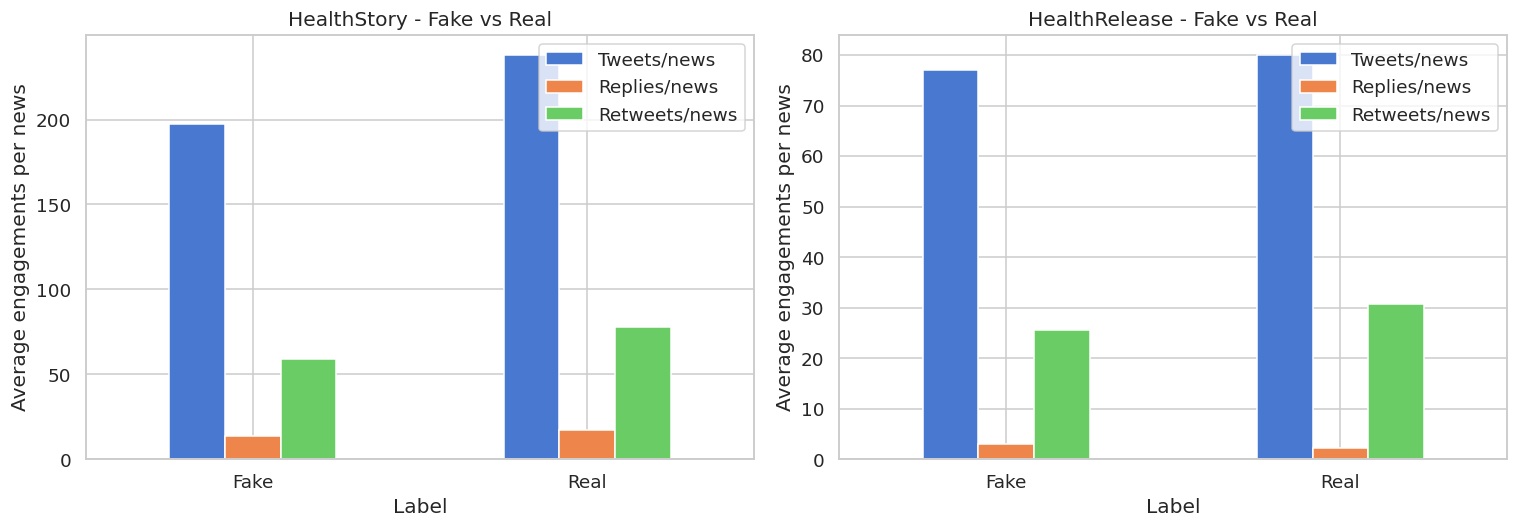

Engagement summary exported: ../dataset/engagement_summary_by_label.csv


In [48]:
# Visualisation des moyennes par news (Fake vs Real)
plot_cols = ['avg_tweets_per_news', 'avg_replies_per_news', 'avg_retweets_per_news']
plot_df = summary_eng_all.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, dataset_name in zip(axes, ['HealthStory', 'HealthRelease']):
    sub = plot_df[plot_df['dataset'] == dataset_name].copy()
    sub = sub.set_index('label_name')[plot_cols]
    sub.columns = ['Tweets/news', 'Replies/news', 'Retweets/news']
    sub.plot(kind='bar', ax=ax)
    ax.set_title(f'{dataset_name} - Fake vs Real')
    ax.set_xlabel('Label')
    ax.set_ylabel('Average engagements per news')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Export CSV pour le rapport
eng_summary_path = os.path.join(REPO_ROOT, 'dataset', 'engagement_summary_by_label.csv')
summary_eng_all.to_csv(eng_summary_path, index=False)
print(f'Engagement summary exported: {eng_summary_path}')

---
## Section 6 — Longueur des textes
Analyse de la longueur des contenus (`text`) pour HealthStory et HealthRelease.


HealthStory - text length stats
count     1638.000000
mean      3812.087912
std       2451.565462
min          0.000000
25%       2223.250000
50%       3659.000000
75%       4947.750000
90%       6720.600000
max      23597.000000

HealthRelease - text length stats
count      599.000000
mean      4810.869783
std       2449.453950
min          0.000000
25%       3395.000000
50%       4385.000000
75%       5665.500000
90%       7027.600000
max      29318.000000


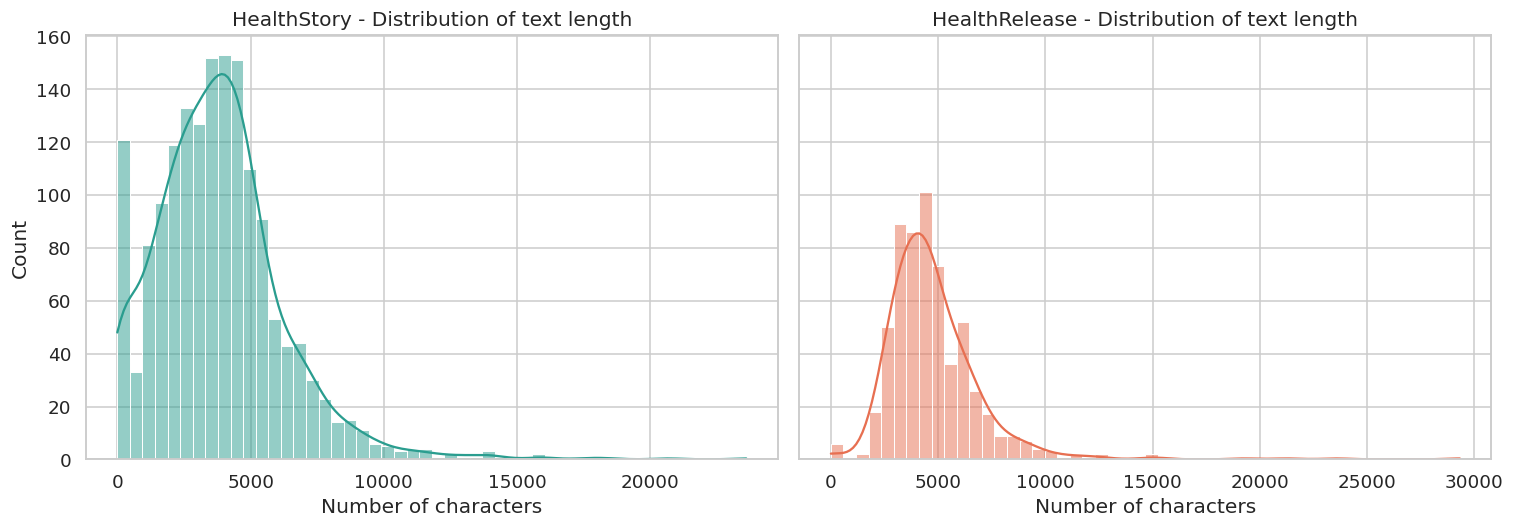

In [29]:
for name, df in [('HealthStory', df_story), ('HealthRelease', df_release)]:
    df['text_len'] = df['text'].fillna('').str.len()
    print(f'\n{name} - text length stats')
    print(df['text_len'].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (name, df), color in zip(axes, [('HealthStory', df_story), ('HealthRelease', df_release)], ['#2a9d8f', '#e76f51']):
    sns.histplot(df['text_len'], bins=50, kde=True, ax=ax, color=color)
    ax.set_title(f'{name} - Distribution of text length')
    ax.set_xlabel('Number of characters')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## Section 7 — Mots dominants (topics simples)
Extraction des mots les plus fréquents pour une vue rapide des sujets dominants.

In [37]:
def top_words(df, text_col='text', n=50):
    vec = CountVectorizer(stop_words='english', max_features=10000)
    X = vec.fit_transform(df[text_col].fillna(''))
    freqs = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    top_idx = freqs.argsort()[::-1][:n]
    return pd.DataFrame({
        'word': vocab[top_idx],
        'count': freqs[top_idx]
    })

for name, df in [('HealthStory', df_story), ('HealthRelease', df_release)]:
    print(f'\n{name} - Top 50 words')
    display(top_words(df, n=50))


HealthStory - Top 50 words


,word,count
0,said,6521
1,study,5606
2,patients,4872
3,cancer,4384
4,people,3300
5,new,3130
6,says,3019
7,women,2592
8,risk,2510
9,treatment,2371



HealthRelease - Top 50 words


,word,count
0,patients,2903
1,study,2643
2,cancer,2342
3,research,1762
4,treatment,1579
5,health,1423
6,said,1196
7,disease,1110
8,risk,1071
9,university,1036


---
## Section 8 — Analyse des critères C1..C8, S9..S10, R9..R10
Cette section transforme les critères textuels des reviews en codes normalisés et calcule un résumé quantitatif.

In [40]:
def map_criterion_code(question: str):
    q = str(question).strip().lower()

    if 'compare the new approach with existing alternatives' in q:
        return 'C1'
    if 'explain/quantify the harms' in q:
        return 'C2'
    if 'grasp the quality of the evidence' in q:
        return 'C3'
    if 'quantify the benefits' in q:
        return 'C4'
    if 'true novelty of the approach' in q:
        return 'C5'
    if 'establish the availability' in q:
        return 'C6'
    if 'commit disease-mongering' in q:
        return 'C7'
    if 'discuss the costs' in q:
        return 'C8'
    if 'use independent sources and identify conflicts of interest' in q:
        return 'S9'
    if 'rely solely or largely on a news release' in q:
        return 'S10'
    if 'identify funding sources & disclose conflicts of interest' in q:
        return 'R9'
    if 'include unjustifiable, sensational language' in q:
        return 'R10'

    return None


def answer_to_score(answer: str):
    a = str(answer).strip().lower()
    if a == 'satisfactory':
        return 1.0
    if a == 'not satisfactory':
        return 0.0
    return np.nan  # Not Applicable


def load_reviews_raw(review_path):
    with open(review_path, 'r', encoding='utf-8') as f:
        return json.load(f)


def explode_criteria_from_raw(review_items, source_type):
    rows = []
    for item in review_items:
        news_id = item.get('news_id', None)
        rating = item.get('rating', np.nan)
        crits = item.get('criteria', [])

        if isinstance(crits, list):
            for c in crits:
                q = c.get('question', None)
                a = c.get('answer', None)
                e = c.get('explanation', None)
                code = map_criterion_code(q)
                if code is None:
                    continue

                rows.append({
                    'news_id': news_id,
                    'source_type': source_type,
                    'rating': rating,
                    'criterion_code': code,
                    'question': q,
                    'answer': a,
                    'score': answer_to_score(a),
                    'explanation': e,
                })

    return pd.DataFrame(rows)


raw_story = load_reviews_raw(PATH_REV_S)
raw_release = load_reviews_raw(PATH_REV_R)

criteria_story = explode_criteria_from_raw(raw_story, 'story')
criteria_release = explode_criteria_from_raw(raw_release, 'release')
criteria_all = pd.concat([criteria_story, criteria_release], ignore_index=True)

print('Rows extracted from criteria:')
print(f'  story   : {len(criteria_story)}')
print(f'  release : {len(criteria_release)}')
print(f'  total   : {len(criteria_all)}')

criterion_order = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'S9', 'S10', 'R9', 'R10']

summary_counts = (
    criteria_all
    .groupby(['criterion_code', 'answer'])
    .size()
    .unstack(fill_value=0)
    .reindex(criterion_order)
    .fillna(0)
    .astype(int)
)

print('\nDistribution by criterion and answer:')
display(summary_counts)

summary_scores = (
    criteria_all
    .groupby('criterion_code')['score']
    .agg(['count', 'mean'])
    .reindex(criterion_order)
)
summary_scores = summary_scores.rename(columns={
    'count': 'n_non_na',
    'mean': 'pct_satisfactory_non_na'
})

print('\nScore summary (excluding Not Applicable in mean):')
display(summary_scores)

criteria_all.head()

Rows extracted from criteria:
  story   : 16899
  release : 6060
  total   : 22959

Distribution by criterion and answer:


answer,,Not Applicable,Not Satisfactory,Satisfactory
criterion_code,,,,
C1,0,113,1120,1063
C2,0,166,1413,717
C3,0,3,1445,848
C4,0,23,1505,768
C5,0,81,672,1543
C6,1,301,537,1457
C7,0,89,286,1921
C8,0,370,1430,495
S9,0,5,820,865



Score summary (excluding Not Applicable in mean):


,n_non_na,pct_satisfactory_non_na
criterion_code,,
C1,2183,0.486945
C2,2130,0.336620
C3,2293,0.369821
C4,2273,0.337879
C5,2215,0.696614
C6,1994,0.730692
C7,2207,0.870412
C8,1925,0.257143
S9,1685,0.513353


,news_id,source_type,rating,criterion_code,question,answer,score,explanation
0,story_reviews_00000,story,1,C8,Does the story adequately discuss the costs of...,Not Satisfactory,0.0,Cost is not discussed. And there are multiple ...
1,story_reviews_00000,story,1,C4,Does the story adequately quantify the benefit...,Not Applicable,NaN,This is tricky. The study has not yet taken pl...
2,story_reviews_00000,story,1,C2,Does the story adequately explain/quantify the...,Not Satisfactory,0.0,"The big risk here, as with any screening test,..."
3,story_reviews_00000,story,1,C3,Does the story seem to grasp the quality of th...,Not Satisfactory,0.0,The story offers a rough overview of the size ...
4,story_reviews_00000,story,1,C7,Does the story commit disease-mongering?,Satisfactory,1.0,No disease mongering here.


---
## Section 9 — Export des fichiers pour NB2
Export d'un CSV prêt pour le baseline classifier sur HealthStory.

In [49]:
export_cols = ['file_id', 'title', 'text', 'label', 'label_name', 'rating_float', 'dataset']

missing_cols = [c for c in export_cols if c not in df_story.columns]
if missing_cols:
    raise KeyError(f'Missing columns for export: {missing_cols}')

output_story = os.path.join(REPO_ROOT, 'dataset', 'healthstory_baseline_ready.csv')
df_story[export_cols].to_csv(output_story, index=False)

print(f'Export OK: {output_story}')
print(f'Rows: {len(df_story)}')

audit_path = os.path.join(REPO_ROOT, 'dataset', 'criteria_summary_nb1.csv')
summary_scores.reset_index().to_csv(audit_path, index=False)
print(f'Criteria summary exported: {audit_path}')

Export OK: ../dataset/healthstory_baseline_ready.csv
Rows: 1638
Criteria summary exported: ../dataset/criteria_summary_nb1.csv
